In [1]:
#1 Menjalankan kueri sederhana pada dataset di spark sql
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Pertemuan9').getOrCreate()

data = [
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
]
columns = ['Name', 'Age', 'Gender', 'Salary', 'DeptId']
df = spark.createDataFrame(data, schema=columns)
df.createOrReplaceTempView('employees')
spark.sql('SELECT Name, Age FROM employees WHERE Salary > 3000').show()
spark.sql('SELECT AVG(Salary) FROM employees').show()

25/10/28 19:56:01 WARN Utils: Your hostname, zulfalab-VirtualBox resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
25/10/28 19:56:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/28 19:56:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

+----+---+
|Name|Age|
+----+---+
|Anna| 28|
+----+---+



[Stage 2:>                                                          (0 + 2) / 2]

+------------------+
|       avg(Salary)|
+------------------+
|3266.6666666666665|
+------------------+



In [2]:
#2 SQL kueri menghitung total gaji berdasarkan jenis kelamin dan usia
spark.sql('''
SELECT Gender, SUM(Salary) as TotalSalary, Age
FROM employees
GROUP BY Gender, Age
ORDER BY Age
''').show()

[Stage 7:>                                                          (0 + 1) / 1]

+------+-----------+---+
|Gender|TotalSalary|Age|
+------+-----------+---+
|     M|       2700| 23|
|     F|       4100| 28|
|     M|       3000| 34|
+------+-----------+---+



In [3]:
# Tugas tambahan 2

# 2.1 Mencari rata-rata gaji per departemen
print("Rata-rata gaji per departemen")
spark.sql('''
SELECT DeptId, AVG(Salary) as RataGaji
FROM employees
GROUP BY DeptId
''').show()

# 2.2 Menemukan karyawan yang memiliki gaji di atas rata-rata untuk gender masing-masing
print("Karyawan yang memiliki gaji di atas rata-rata untuk gender masing-masing")
rata_gaji_pergender = spark.sql('''
SELECT Gender, AVG(Salary) AS RataGajiBerdasarkanGender 
FROM employees
GROUP BY Gender
''')
rata_gaji_pergender.createOrReplaceTempView("rata_gaji_pergender")
spark.sql('''
SELECT e.Name, e.Gender, e.Salary, r.RataGajiBerdasarkanGender
FROM employees e
JOIN rata_gaji_pergender r ON e.Gender = r.Gender
WHERE e.Salary > r.RataGajiBerdasarkanGender
ORDER BY e.Gender, e.Salary DESC
''').show()

# 2.3 Ranking karyawan berdasarkan gaji dalam departemen mereka
print("Ranking karyawan berrdasarkan gaji dalam departemen mereka")
from pyspark.sql.window import Window
from pyspark.sql.functions import desc
ranking_karyawan = Window.partitionBy("DeptId").orderBy(desc("Salary"))
from pyspark.sql.functions import row_number
df.withColumn("RankGajidiDept", row_number().over(ranking_karyawan)).orderBy("DeptId", "RankGajidiDept").show()


Rata-rata gaji per departemen


+------+--------+
|DeptId|RataGaji|
+------+--------+
|     1|  2850.0|
|     2|  4100.0|
+------+--------+

Karyawan yang memiliki gaji di atas rata-rata untuk gender masing-masing
+-----+------+------+-------------------------+
| Name|Gender|Salary|RataGajiBerdasarkanGender|
+-----+------+------+-------------------------+
|James|     M|  3000|                   2850.0|
+-----+------+------+-------------------------+

Ranking karyawan berrdasarkan gaji dalam departemen mereka
+-----+---+------+------+------+--------------+
| Name|Age|Gender|Salary|DeptId|RankGajidiDept|
+-----+---+------+------+------+--------------+
|James| 34|     M|  3000|     1|             1|
|  Lee| 23|     M|  2700|     1|             2|
| Anna| 28|     F|  4100|     2|             1|
+-----+---+------+------+------+--------------+



In [4]:
#3. Penggunaan Window Functions dan Subqueries 
spark.sql('''
SELECT Name, Age, Salary, ROW_NUMBER() OVER (PARTITION BY Age ORDER BY Salary DESC) as rank
FROM employees
''').show()

+-----+---+------+----+
| Name|Age|Salary|rank|
+-----+---+------+----+
|  Lee| 23|  2700|   1|
| Anna| 28|  4100|   1|
|James| 34|  3000|   1|
+-----+---+------+----+



In [5]:
# Tugas 3: Menerapkan window functions untuk menemukan top 3 karyawan dalam kelompok usia tertentu
print("Window functions untuk menemukan top 3 karyawan dalam kelompok usia tertentu")
from pyspark.sql.functions import floor, col
df2 = df.withColumn("GroupUmur", (col("Age")/10).cast("int")*10)
df2.createOrReplaceTempView("df2")
spark.sql('''
SELECT Name, Age, GroupUmur, Salary,
ROW_NUMBER() OVER (PARTITION BY GroupUmur ORDER BY Salary DESC) as rank
FROM df2
''').where("rank <= 3").orderBy("GroupUmur", "rank").show()

Window functions untuk menemukan top 3 karyawan dalam kelompok usia tertentu


[Stage 22:=============================>                            (1 + 1) / 2]

+-----+---+---------+------+----+
| Name|Age|GroupUmur|Salary|rank|
+-----+---+---------+------+----+
| Anna| 28|       20|  4100|   1|
|  Lee| 23|       20|  2700|   2|
|James| 34|       30|  3000|   1|
+-----+---+---------+------+----+



In [6]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Pertemuan9').getOrCreate()

employees = spark.createDataFrame([
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
], ['Name', 'Age', 'Gender', 'Salary', 'DeptId'])
departments = spark.createDataFrame([
    (1, 'HR'),
    (2, 'Marketing')
], ['DeptId', 'DeptName'])
projects = spark.createDataFrame([
    (1, 'Project A'),
    (2, 'Project B')
], ['DeptId', 'ProjectName'])
employees.createOrReplaceTempView('employees')
departments.createOrReplaceTempView('departments')
projects.createOrReplaceTempView('Projects')

spark.sql('''
SELECT e.name, e.Age, d.DeptName, p.ProjectName
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
JOIN projects p ON e.DeptId = p.DeptId
''').show()

+-----+---+---------+-----------+
| name|Age| DeptName|ProjectName|
+-----+---+---------+-----------+
|  Lee| 23|       HR|  Project A|
|James| 34|       HR|  Project A|
| Anna| 28|Marketing|  Project B|
+-----+---+---------+-----------+



In [36]:
# Tugas 5: Tuliskan query SQL untuk menemukan rata-rata gaji per departemen dan ranking setiap karyawan dalam departemen berdasarkan gaji
print("rata-rata gaji setiap departemen")
spark.sql('''
SELECT d.DeptName, AVG(e.Salary) AS AvgSalary
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
GROUP BY d.DeptName
''').show()

print("ranking karyawan dalam departement")
w = Window.partitionBy("DeptId").orderBy(desc("Salary"))
from pyspark.sql.functions import dense_rank
employees.withColumn("RankInDept", dense_rank().over(w)).orderBy("DeptId", "RankInDept").show()

rata-rata gaji setiap departemen
+---------+---------+
| DeptName|AvgSalary|
+---------+---------+
|       HR|   2850.0|
|Marketing|   4100.0|
+---------+---------+

ranking karyawan dalam departement
+-----+---+------+------+------+----------+
| Name|Age|Gender|Salary|DeptId|RankInDept|
+-----+---+------+------+------+----------+
|James| 34|     M|  3000|     1|         1|
|  Lee| 23|     M|  2700|     1|         2|
| Anna| 28|     F|  4100|     2|         1|
+-----+---+------+------+------+----------+



In [7]:
# Tugas 6: Window functions untuk menentukan tren gaji berdasarkan usia di setiap departemen
from pyspark.sql.functions import avg as _avg
print("tren gaji berdasarkan usia di setiap departemen")
umur_dept_rata = df.groupBy("DeptId", "Age").agg(_avg("Salary").alias("RataGajiBrdasrkanUmur"))
w_trend = Window.partitionBy("DeptId").orderBy("Age")
from pyspark.sql.functions import lag
umur_dept_rata = umur_dept_rata.withColumn("PrevAvg", lag("RataGajiBrdasrkanUmur").over(w_trend))
umur_dept_rata.orderBy("DeptId", "Age").show()

tren gaji berdasarkan usia di setiap departemen
+------+---+---------------------+-------+
|DeptId|Age|RataGajiBrdasrkanUmur|PrevAvg|
+------+---+---------------------+-------+
|     1| 23|               2700.0|   NULL|
|     1| 34|               3000.0| 2700.0|
|     2| 28|               4100.0|   NULL|
+------+---+---------------------+-------+



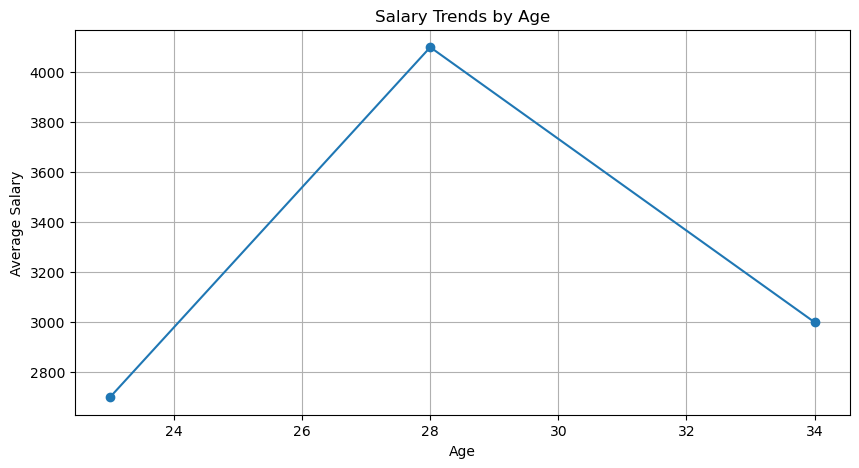

In [8]:
# Tugas 7: Lakukan analisis tren gaji menggunakan Spark SQL dan visualisasikan hasilnya.
import matplotlib.pyplot as plt
import pandas as pd

salary_trends = spark.sql('''
SELECT Age, AVG(Salary) AS AverageSalary
FROM employees
GROUP BY Age
ORDER BY Age
''').toPandas()

plt.figure(figsize=(10, 5))
plt.plot(salary_trends['Age'], salary_trends['AverageSalary'], marker='o')
plt.xlabel('Age')
plt.ylabel('Average Salary')
plt.title('Salary Trends by Age')
plt.grid(True)
plt.show()

In [5]:
# Homework:
# Tugas 1: Gunakan Spark SQL untuk mencari total gaji dan jumlah karyawan per departemen. Buat visualisasi perbandingan antar departemen.
# Tugas 2: Temukan karyawan dengan gaji di atas rata-rata dalam setiap kelompok usia dan visualisasikan data ini dalam bentuk grafik batang atau pie chart.
# Tugas 3: Buat dataset yang lebih besar (misalnya, 100+ baris) dan lakukan analisis mendalam menggunakan SQL functions seperti SUM(), AVG(),COUNT(), serta JOIN antar tabel serta buat visualisasi yang menarik.
from pyspark.sql import SparkSession
from pyspark.sql.functions import round as _round, col, avg as _avg, sum as _sum, count as _count
from pyspark.sql.functions import when
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName("Homework_dataset") \
    .master("local[*]") \
    .getOrCreate()

departments_data = [
    (1, 'HR'),
    (2, 'Finance'),
    (3, 'Engineering'),
    (4, 'Marketing'),
    (5, 'Operations')
]
departments = spark.createDataFrame(departments_data, ['DeptId', 'DeptName'])
departments.createOrReplaceTempView("departments")

employees_data = [
    # Dept 1 - HR (20)
    ('Alice', 25, 'F', 3400, 1),('Bob', 28, 'M', 3600, 1),('Cindy', 31, 'F', 3800, 1),('David', 33, 'M', 4000, 1),
    ('Eva', 29, 'F', 3700, 1),('Frank', 42, 'M', 5200, 1),('Grace', 38, 'F', 4600, 1),('Henry', 41, 'M', 5100, 1),
    ('Irene', 30, 'F', 3900, 1),('Jack', 35, 'M', 4400, 1),('Kara', 27, 'F', 3600, 1),('Leo', 45, 'M', 5500, 1),
    ('Maya', 39, 'F', 4800, 1),('Nick', 40, 'M', 5000, 1),('Olivia', 32, 'F', 4100, 1),('Peter', 36, 'M', 4500, 1),
    ('Queen', 29, 'F', 3700, 1),('Ryan', 37, 'M', 4600, 1),('Sophia', 33, 'F', 4200, 1),('Tom', 31, 'M', 4000, 1),

    # Dept 2 - Finance (20)
    ('Uma', 26, 'F', 3600, 2),('Victor', 28, 'M', 3700, 2),('Wendy', 35, 'F', 4700, 2),('Xander', 40, 'M', 5200, 2),
    ('Yara', 39, 'F', 4900, 2),('Zack', 30, 'M', 4100, 2),('Aaron', 42, 'M', 5400, 2),('Bella', 33, 'F', 4300, 2),
    ('Charles', 31, 'M', 4000, 2),('Diana', 29, 'F', 3900, 2),('Ethan', 37, 'M', 4600, 2),('Fiona', 34, 'F', 4400, 2),
    ('George', 36, 'M', 4700, 2),('Hannah', 38, 'F', 4900, 2),('Ian', 45, 'M', 5500, 2),('Jane', 28, 'F', 3700, 2),
    ('Kyle', 41, 'M', 5200, 2),('Laura', 32, 'F', 4200, 2),('Mark', 39, 'M', 5000, 2),('Nina', 30, 'F', 4000, 2),

    # Dept 3 - Engineering (20)
    ('Oscar', 27, 'M', 3900, 3),('Paula', 34, 'F', 4800, 3),('Quentin', 36, 'M', 5100, 3),('Rita', 31, 'F', 4500, 3),
    ('Sam', 40, 'M', 5700, 3),('Tina', 29, 'F', 4200, 3),('Umar', 43, 'M', 6000, 3),('Vera', 38, 'F', 5300, 3),
    ('Will', 35, 'M', 5000, 3),('Xenia', 32, 'F', 4600, 3),('Yusuf', 41, 'M', 5800, 3),('Zara', 37, 'F', 5200, 3),
    ('Andy', 30, 'M', 4400, 3),('Betty', 33, 'F', 4700, 3),('Carl', 45, 'M', 6100, 3),('Daisy', 28, 'F', 4100, 3),
    ('Evan', 39, 'M', 5500, 3),('Faith', 26, 'F', 3800, 3),('Garry', 44, 'M', 5900, 3),('Hazel', 29, 'F', 4200, 3),

    # Dept 4 - Marketing (20)
    ('Ivan', 27, 'M', 3500, 4),('Jenna', 28, 'F', 3600, 4),('Kevin', 30, 'M', 3900, 4),('Luna', 32, 'F', 4200, 4),
    ('Morris', 35, 'M', 4600, 4),('Nadia', 29, 'F', 3700, 4),('Owen', 37, 'M', 4900, 4),('Penny', 33, 'F', 4100, 4),
    ('Quinn', 40, 'M', 5200, 4),('Rosa', 31, 'F', 4000, 4),('Steve', 42, 'M', 5400, 4),('Tara', 39, 'F', 4800, 4),
    ('Ulrich', 36, 'M', 4600, 4),('Vicky', 28, 'F', 3700, 4),('Walt', 45, 'M', 5600, 4),('Ximena', 34, 'F', 4300, 4),
    ('Yohan', 41, 'M', 5300, 4),('Zoey', 38, 'F', 4700, 4),('Adam', 29, 'M', 3800, 4),('Bianca', 26, 'F', 3500, 4),

    # Dept 5 - Operations (20)
    ('Chris', 27, 'M', 3700, 5),('Dora', 30, 'F', 4000, 5),('Eli', 32, 'M', 4200, 5),('Fara', 28, 'F', 3800, 5),
    ('Glen', 34, 'M', 4500, 5),('Hilda', 31, 'F', 4100, 5),('Isaac', 36, 'M', 4700, 5),('Jolie', 33, 'F', 4400, 5),
    ('Kurt', 39, 'M', 5000, 5),('Lara', 29, 'F', 3900, 5),('Mike', 40, 'M', 5200, 5),('Nora', 35, 'F', 4600, 5),
    ('Omar', 37, 'M', 4900, 5),('Paige', 28, 'F', 3800, 5),('Quincy', 43, 'M', 5600, 5),('Renee', 30, 'F', 4000, 5),
    ('Shawn', 38, 'M', 5100, 5),('Tessa', 33, 'F', 4400, 5),('Ulysses', 41, 'M', 5300, 5),('Vera_Ops', 34, 'F', 4500, 5)
]

employees = spark.createDataFrame(employees_data, ['Name', 'Age', 'Gender', 'Salary', 'DeptId'])
employees.createOrReplaceTempView("employees")

25/10/28 20:25:28 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.



Tugas 1: Total gaji & jumlah karyawan per departemen
+-----------+--------------+---------+------------+
|   DeptName|JumlahKaryawan|TotalGaji|RataRataGaji|
+-----------+--------------+---------+------------+
|Engineering|            20|    98800|      4940.0|
|    Finance|            20|    90000|      4500.0|
| Operations|            20|    89700|      4485.0|
|  Marketing|            20|    87400|      4370.0|
|         HR|            20|    85700|      4285.0|
+-----------+--------------+---------+------------+



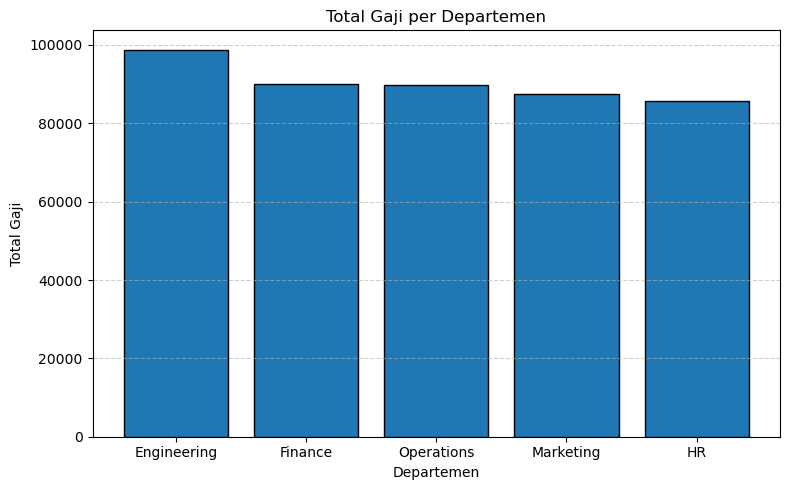

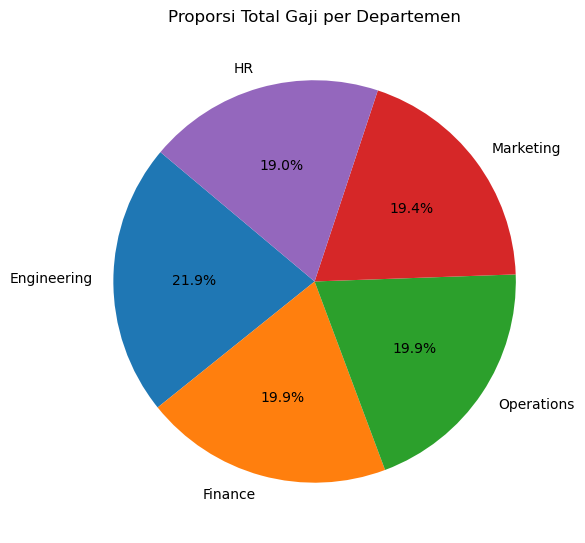

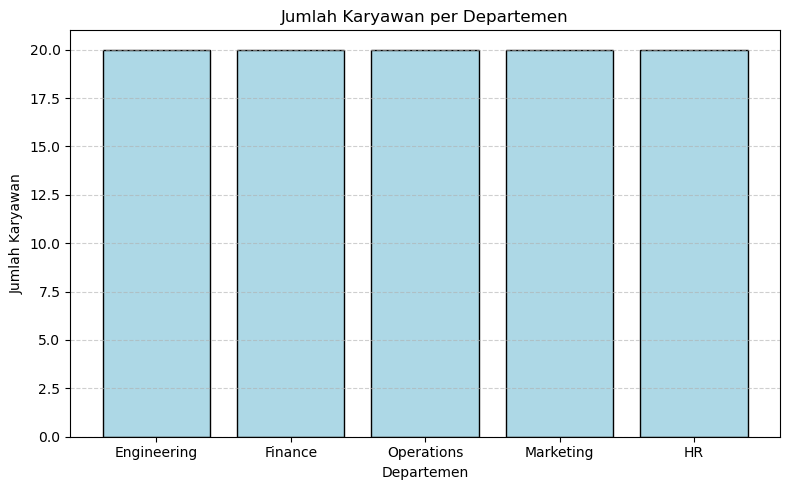

In [7]:
# Tugas 1: Gunakan Spark SQL untuk mencari total gaji dan jumlah karyawan per departemen. Buat visualisasi perbandingan antar departemen.

t1 = spark.sql("""
SELECT d.DeptName,
       COUNT(*) AS JumlahKaryawan,
       ROUND(SUM(e.Salary),2) AS TotalGaji,
       ROUND(AVG(e.Salary),2) AS RataRataGaji
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
GROUP BY d.DeptName
ORDER BY TotalGaji DESC
""")
t1.createOrReplaceTempView("t1_dept_salary_count")
print("\nTugas 1: Total gaji & jumlah karyawan per departemen")
t1.show()

# bar chart
pdf_t1 = t1.toPandas()
plt.figure(figsize=(8,5))
plt.bar(pdf_t1['DeptName'], pdf_t1['TotalGaji'], edgecolor='black')
plt.title('Total Gaji per Departemen')
plt.xlabel('Departemen')
plt.ylabel('Total Gaji')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# pie chart
plt.figure(figsize=(6,6))
plt.pie(pdf_t1['TotalGaji'], labels=pdf_t1['DeptName'], autopct='%1.1f%%', startangle=140)
plt.title('Proporsi Total Gaji per Departemen')
plt.tight_layout()
plt.show()

# bar chart
plt.figure(figsize=(8,5))
plt.bar(pdf_t1['DeptName'], pdf_t1['JumlahKaryawan'], edgecolor='black', color='lightblue')
plt.title('Jumlah Karyawan per Departemen')
plt.xlabel('Departemen')
plt.ylabel('Jumlah Karyawan')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



Rata-rata gaji per kelompok usia
+--------+---------+
|AgeGroup|AvgSalary|
+--------+---------+
|     20s|  3754.17|
|     30s|  4505.36|
|     40s|   5460.0|
+--------+---------+


Karyawan dengan gaji di atas rata-rata per kelompok usia (sample 50)


+-------+---+--------+------+------+-----------+
|   Name|Age|AgeGroup|Gender|Salary|   DeptName|
+-------+---+--------+------+------+-----------+
|  Hazel| 29|     20s|     F|  4200|Engineering|
|   Tina| 29|     20s|     F|  4200|Engineering|
|  Daisy| 28|     20s|     F|  4100|Engineering|
|  Diana| 29|     20s|     F|  3900|    Finance|
|   Lara| 29|     20s|     F|  3900| Operations|
|  Oscar| 27|     20s|     M|  3900|Engineering|
|  Paige| 28|     20s|     F|  3800| Operations|
|   Fara| 28|     20s|     F|  3800| Operations|
|  Faith| 26|     20s|     F|  3800|Engineering|
|   Adam| 29|     20s|     M|  3800|  Marketing|
|   Evan| 39|     30s|     M|  5500|Engineering|
|   Vera| 38|     30s|     F|  5300|Engineering|
|   Zara| 37|     30s|     F|  5200|Engineering|
|  Shawn| 38|     30s|     M|  5100| Operations|
|Quentin| 36|     30s|     M|  5100|Engineering|
|   Kurt| 39|     30s|     M|  5000| Operations|
|   Mark| 39|     30s|     M|  5000|    Finance|
|   Will| 35|     30

+--------+-------------+--------------+
|AgeGroup|CountAboveAvg|AvgSalaryAbove|
+--------+-------------+--------------+
|     20s|           10|        3940.0|
|     30s|           27|       4848.15|
|     40s|            9|       5744.44|
+--------+-------------+--------------+



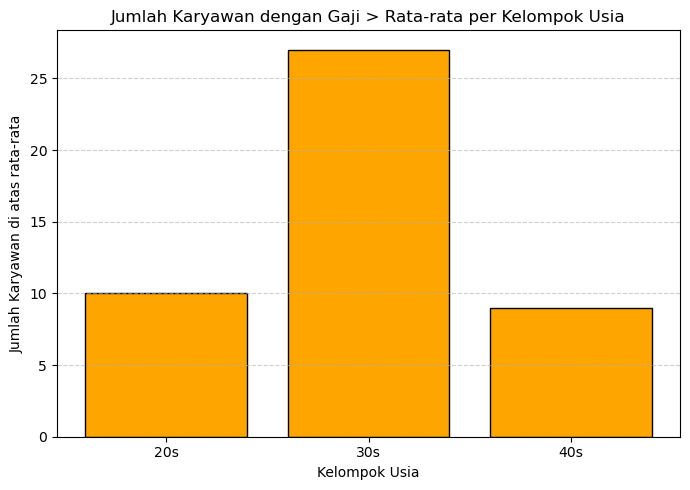

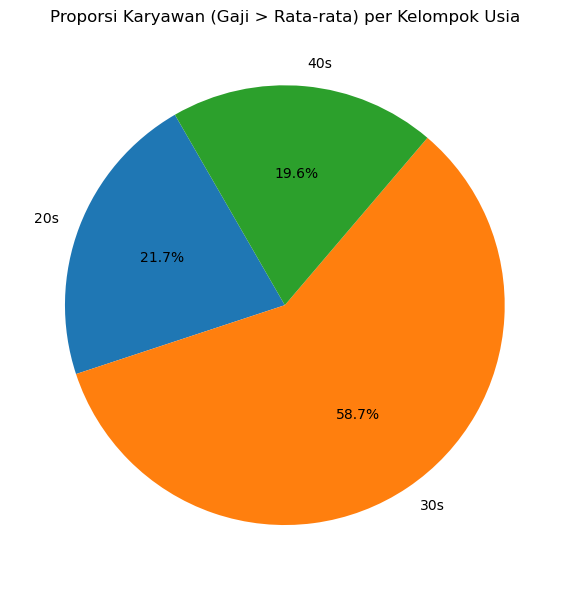

In [9]:
# Tugas 2: Temukan karyawan dengan gaji di atas rata-rata dalam setiap kelompok usia dan visualisasikan data ini dalam bentuk grafik batang atau pie chart.

employees_with_agegroup = employees.withColumn("AgeGroup",
    when((col("Age") >= 20) & (col("Age") < 30), "20s")
    .when((col("Age") >= 30) & (col("Age") < 40), "30s")
    .when((col("Age") >= 40) & (col("Age") < 50), "40s")
    .otherwise("50s+")
)
employees_with_agegroup.createOrReplaceTempView("employees_ag")

spark.sql("""
SELECT AgeGroup, ROUND(AVG(Salary),2) AS AvgSalary
FROM employees_ag
GROUP BY AgeGroup
ORDER BY AgeGroup
""").createOrReplaceTempView("avg_by_agegroup")

print("\nRata-rata gaji per kelompok usia")
spark.sql("SELECT * FROM avg_by_agegroup").show()

spark.sql("""
SELECT e.Name, e.Age, e.AgeGroup, e.Gender, e.Salary, d.DeptName
FROM employees_ag e
JOIN avg_by_agegroup a ON e.AgeGroup = a.AgeGroup
JOIN departments d ON e.DeptId = d.DeptId
WHERE e.Salary > a.AvgSalary
ORDER BY e.AgeGroup, e.Salary DESC
""").createOrReplaceTempView("above_avg_by_agegroup")

print("\nKaryawan dengan gaji di atas rata-rata per kelompok usia (sample 50)")
spark.sql("SELECT * FROM above_avg_by_agegroup LIMIT 50").show()

summary_above = spark.sql("""
SELECT AgeGroup, COUNT(*) AS CountAboveAvg, ROUND(AVG(Salary),2) AS AvgSalaryAbove
FROM above_avg_by_agegroup
GROUP BY AgeGroup
ORDER BY AgeGroup
""")
summary_above.show()
pdf_above = summary_above.toPandas()
# bar chart
plt.figure(figsize=(7,5))
plt.bar(pdf_above['AgeGroup'], pdf_above['CountAboveAvg'], edgecolor='black', color='orange')
plt.title('Jumlah Karyawan dengan Gaji > Rata-rata per Kelompok Usia')
plt.xlabel('Kelompok Usia')
plt.ylabel('Jumlah Karyawan di atas rata-rata')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# pie chart
plt.figure(figsize=(6,6))
plt.pie(pdf_above['CountAboveAvg'], labels=pdf_above['AgeGroup'], autopct='%1.1f%%', startangle=120)
plt.title('Proporsi Karyawan (Gaji > Rata-rata) per Kelompok Usia')
plt.tight_layout()
plt.show()



Tugas 3: Analisis mendalam menggunakan (SUM(), AVG(), COUNT(), JOIN)


+-----------+--------------+---------+------------+-------+-------+
|   DeptName|JumlahKaryawan|TotalGaji|RataRataGaji|GajiMin|GajiMax|
+-----------+--------------+---------+------------+-------+-------+
|Engineering|            20|    98800|      4940.0|   3800|   6100|
|    Finance|            20|    90000|      4500.0|   3600|   5500|
| Operations|            20|    89700|      4485.0|   3700|   5600|
|  Marketing|            20|    87400|      4370.0|   3500|   5600|
|         HR|            20|    85700|      4285.0|   3400|   5500|
+-----------+--------------+---------+------------+-------+-------+



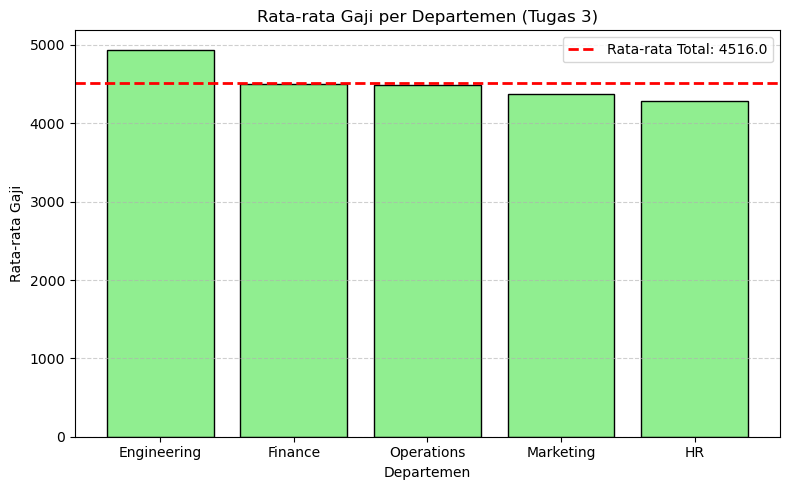

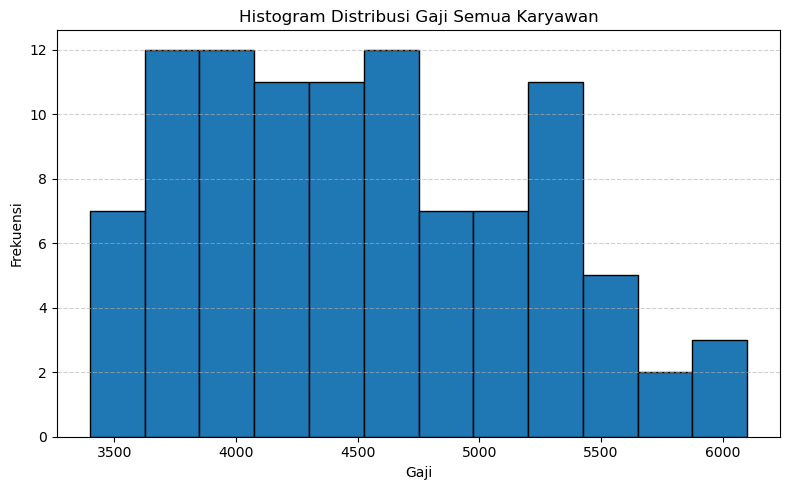

/tmp/ipykernel_3580/4136814355.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=pdf_all['DeptName'].unique(), patch_artist=True)


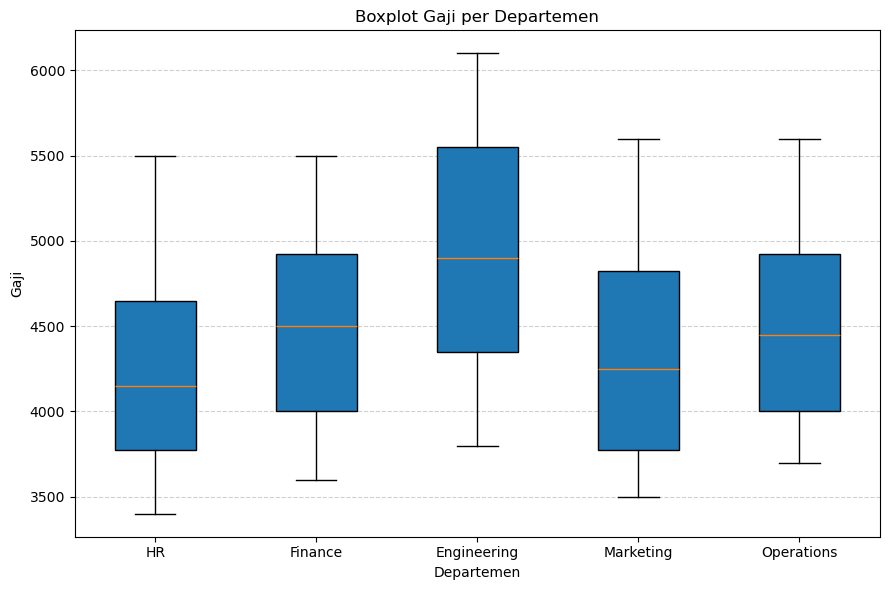


Top 10 Karyawan bergaji tertinggi
+------+---+------+------+-----------+
|Name  |Age|Gender|Salary|DeptName   |
+------+---+------+------+-----------+
|Carl  |45 |M     |6100  |Engineering|
|Umar  |43 |M     |6000  |Engineering|
|Garry |44 |M     |5900  |Engineering|
|Yusuf |41 |M     |5800  |Engineering|
|Sam   |40 |M     |5700  |Engineering|
|Walt  |45 |M     |5600  |Marketing  |
|Quincy|43 |M     |5600  |Operations |
|Leo   |45 |M     |5500  |HR         |
|Ian   |45 |M     |5500  |Finance    |
|Evan  |39 |M     |5500  |Engineering|
+------+---+------+------+-----------+



In [10]:
# Tugas 3: Buat dataset yang lebih besar (misalnya, 100+ baris) dan lakukan analisis mendalam menggunakan SQL functions seperti SUM(), AVG(),COUNT(), serta JOIN antar tabel serta buat visualisasi yang menarik.
deep_stats = spark.sql("""
SELECT d.DeptName,
       COUNT(e.Name) AS JumlahKaryawan,
       ROUND(SUM(e.Salary),2) AS TotalGaji,
       ROUND(AVG(e.Salary),2) AS RataRataGaji,
       ROUND(MIN(e.Salary),2) AS GajiMin,
       ROUND(MAX(e.Salary),2) AS GajiMax
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
GROUP BY d.DeptName
ORDER BY RataRataGaji DESC
""")
print("\nTugas 3: Analisis mendalam menggunakan (SUM(), AVG(), COUNT(), JOIN)")
deep_stats.show()

pdf_deep = deep_stats.toPandas()
avg_total_all = employees.select(_round(_avg(col("Salary")),2).alias("avg_all")).collect()[0]['avg_all']

plt.figure(figsize=(8,5))
plt.bar(pdf_deep['DeptName'], pdf_deep['RataRataGaji'], edgecolor='black', color='lightgreen')
plt.axhline(y=avg_total_all, color='red', linestyle='--', linewidth=2, label=f'Rata-rata Total: {avg_total_all}')
plt.title('Rata-rata Gaji per Departemen (Tugas 3)')
plt.xlabel('Departemen')
plt.ylabel('Rata-rata Gaji')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Histogram 
pdf_salary = employees.select("Salary").toPandas()
plt.figure(figsize=(8,5))
plt.hist(pdf_salary['Salary'], bins=12, edgecolor='black')
plt.title('Histogram Distribusi Gaji Semua Karyawan')
plt.xlabel('Gaji')
plt.ylabel('Frekuensi')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Boxplot 

pdf_all = employees.join(departments, "DeptId").select("DeptName", "Salary").toPandas()
groups = [pdf_all[pdf_all['DeptName'] == d]['Salary'].values for d in pdf_all['DeptName'].unique()]

plt.figure(figsize=(9,6))
plt.boxplot(groups, labels=pdf_all['DeptName'].unique(), patch_artist=True)
plt.title('Boxplot Gaji per Departemen')
plt.xlabel('Departemen')
plt.ylabel('Gaji')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nTop 10 Karyawan bergaji tertinggi")
spark.sql("""
SELECT e.Name, e.Age, e.Gender, e.Salary, d.DeptName
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
ORDER BY e.Salary DESC
LIMIT 10
""").show(truncate=False)
